# 03 — Feature Analysis

Notebook 02 settled what the label measures. This one looks at what data go into the model, and at what most of those columns can actually do.

The output is `data/features/feature_table.parquet` which consists of **44,684 ranked listings × 66 columns**,
of which **61 are features**, sorted into **393 query groups**. Every column can be computed from data available before that
listing's own T, so nothing reads the label window.

## Summary

Two things came up again and again while building these features, so here they are before the
evidence:

> A feature that has a constant value inside a query group can't separate any pair. It can still help
> the model *condition* — read other features differently in different contexts — but it can
> never tell two listings in the same search apart, however high it climbs in an importance
> chart.
>
> Leave-one-out doesn't make an aggregate of the label safe. At query-group scale it turns
> into a perfect answer key (§7).

Three things follow, in order below:

1. **The query group is a design decision with a measurable cost** — 393 groups, no
   singletons, 99.4 % of listings on the primary key (§1) — and about a third of the numeric
   features turn out to be near-constant inside a group (§2).
2. **What's absent matters as much as what's here.** No neighbourhood mean of the target (§7),
   no sentiment score (§9), no imputed `bedrooms` (§4), no price anywhere in the grade.
3. **The baselines are frozen, and the floor is high.** Ranking by review count scores NDCG@10
   **0.6424**; random scores **0.5424**.

## 0. Setup

There are two objects:
- `matrix` is the shipped feature table, read from disk exactly as the training job
will read it. 
- `ranked` is the pre-assembly population, rebuilt here because a few sections need
columns `neighbourhood_cleansed`, `amenities` the that are deliberately *not* features

The `prepare_ranked` function runs the  pipeline (label → filters → price → grades) and then the grouping,
printing each stage's report.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from rental_ranking import eda
from rental_ranking.data.columns import LABEL_ADJACENT_COLUMNS
from rental_ranking.data.paths import FEATURE_TABLE_PATH, PROCESSED_DIR
from rental_ranking.features.amenities import AMENITY_BUCKETS, bucket_of, canonicalise
from rental_ranking.features.assemble import (
    IDENTIFIER_COLUMNS,
    PHASE1_DIAGNOSTIC_COLUMNS,
    TARGET_COLUMNS,
    check_feature_table,
    feature_columns,
)
from rental_ranking.features.build import prepare_ranked
from rental_ranking.features.groups import group_sizes, query_group
from rental_ranking.features.label import DEFAULT_PARTITION_COLS
from rental_ranking.features.spatial import ANCHORS

pd.set_option("display.width", 120)

matrix = pd.read_parquet(FEATURE_TABLE_PATH)
FEATURES = feature_columns(matrix)
QG = matrix["query_group"]
LABEL = "blocked_fraction_90"
CITIES = ["thessaloniki", "athens", "crete"]

listings_df = pd.read_parquet(PROCESSED_DIR / "listings.parquet")
calendar_df = pd.read_parquet(PROCESSED_DIR / "calendar.parquet")
ranked = prepare_ranked(listings_df, calendar_df)
del calendar_df, listings_df

print(f"\nmatrix  {matrix.shape[0]:,} rows x {matrix.shape[1]} cols  ({len(FEATURES)} features)")


filters — 46,635 listings in, 44,684 kept
                  n  inactive  long_term  dormant  extreme_price  multi_rule  removed   kept
city                                                                                        
athens        14337       101          1        2             14           0      118  14219
crete         27333       523         43     1279              7         295     1556  25777
thessaloniki   4965        75         25      222              4          48      277   4688

price imputation — rows filled per cascade rung
                  n  missing  nbhd_room_accommodates  nbhd_room_tier  nbhd_room  city_room  city
city                                                                                            
athens        14219      120                     120               0          0          0     0
crete         25777      541                     540               1          0          0     0
thessaloniki   4688       33                      32   

## 1. What is a query group, and what did the fallback cost?

A query group stands in for "one user search". The key is
`city × neighbourhood_cleansed × room_type × capacity_tier`, the four things a user actually
fixes before results are ranked. Our metric, NDCG, is computed inside one group.

**What the table below shows.** The fallback cascade's three rungs and how much traffic each
carried. A group smaller than 5 falls to the next rung; the fallers **pool among themselves**
and never re-open a group that has already settled, so the primary rung's composition is
never disturbed by a later one.

In [2]:
_, rung_report = query_group(ranked)
rung_report

,key,n,groups,singletons,under_minimum,median_size
rung,,,,,,
nbhd_room_tier,city x neighbourhood_cleansed x room_type x ca...,44395,363,0,0,34.0
city_room_tier,city x room_type x capacity_tier,255,21,0,0,10.0
city_room,city x room_type,34,9,0,7,3.0


**99.4 % of listings are grouped by the primary key.** 44,395 rows sit on the full four-part
key; 255 are formed by dropping the neighbourhood and 34 by dropping capacity as well. The cost is the 289 listings (0.6 %) that rank against a broader set than the initial key.

Seven groups still sit under the minimum of 5 listings. All of them are on the last rung, because
`city × room_type` is the coarsest key that still keeps the grading partition's columns.

**What the table below shows.** The resulting group-size distribution.

In [3]:
sizes = QG.value_counts()
display(
    pd.Series(
        {
            "query groups": len(sizes),
            "singletons": int((sizes == 1).sum()),
            "under minimum (5)": int((sizes < 5).sum()),
            "smallest": int(sizes.min()),
            "median": int(sizes.median()),
            "largest": int(sizes.max()),
            "grade array sums to rows": int(group_sizes(QG).sum()) == len(matrix),
        }
    ).to_frame("value")
)

# A coarsening, not a cross-cut: every group must sit inside exactly one grading partition.
partition = ranked[list(DEFAULT_PARTITION_COLS)].astype(str).agg("|".join, axis=1)
print("partitions touched per query group:", ranked.groupby("query_group")
      .apply(lambda g: partition.loc[g.index].nunique(), include_groups=False).max())

,value
query groups,393
singletons,0
under minimum (5),7
smallest,2
median,29
largest,2088
grade array sums to rows,True


partitions touched per query group: 1


**No singletons, median 29, largest 2,088.** The spread is the challenging part as NDCG@10 over
2,088 listings and NDCG@10 over 6 are different measurements.

The important thing is that every query group sits inside exactly **one** grading partition. That is what stops the grade
from contradicting the label.

## 2. Which features can actually separate two listings?

A pairwise ranker learns from *differences
within a group*. A feature that is constant inside a group contributes nothing to any pair, no
matter how strongly it correlates with the label overall.

`room_type` and `city` columns are the clearest cases: both are **in the group key**, so they are
constant within a group by construction. They are still worth carrying, because a tree can
condition on them to change how it reads the other features, but they condition rather than
discriminate.

**What the two tables below show.** For each numeric feature, its average variance within a query
group divided by its overall variance (`within-group variance / overall variance`). Values near **0** means a feature is effectively constant inside a group, so it
cannot separate a pair. Near or above **1** means it varies inside a group as much as it does
anywhere.

In [4]:
numeric = matrix[FEATURES].select_dtypes("number")
ratio = (
    (numeric.groupby(QG).var().mean() / numeric.var())
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values()
)
display(pd.DataFrame({"within / overall variance": ratio.head(10).round(3)}))
display(pd.DataFrame({"within / overall variance": ratio.tail(10).round(3)}))

,within / overall variance
nbhd_listings,0.015
nbhd_median_price,0.034
density_1km,0.091
km_to_nearest_anchor,0.12
accommodates,0.166
km_to_neighbourhood_centroid,0.319
calculated_host_listings_count_entire_homes,0.377
calculated_host_listings_count,0.399
amenity_outdoor_space,0.443
bedrooms,0.476


,within / overall variance
review_scores_location,1.271
minimum_nights,1.277
review_scores_value,1.317
review_scores_accuracy,1.365
review_scores_cleanliness,1.402
review_scores_communication,1.422
review_scores_checkin,1.434
calculated_host_listings_count_private_rooms,1.72
maximum_nights,1.779
calculated_host_listings_count_shared_rooms,3.795


`nbhd_listings` (0.015) and `nbhd_median_price` (0.034) are near-constant because the
neighbourhood is part of the key. This makes sense: a neighbourhood aggregate can't vary inside a group that sits
in one neighbourhood. `density_1km` (0.091) and `km_to_nearest_anchor` (0.12) follow for the
same geographic reason, and `accommodates` (0.166) because `capacity_tier` is a coarsening of
it.

**The discriminators are the review sub-scores and the host-portfolio counts.** The six Airbnb
review scores land at 1.32–1.43. They are the ones that vary *more* within a group than across the whole
population. Ratios above 1 mean groups concentrate the variation
instead of averaging it away.

## 3. Three column roles

**What the tables below show.** A breakdown of the columns in the training set by feature category.

We include the label, `blocked_fraction_90` for analysis and is **not** a feature. `query_group` is an
identifier rather than an input.

In [5]:
def block_of(column: str) -> str:
    if column in set(IDENTIFIER_COLUMNS) | set(TARGET_COLUMNS):
        return "0 key / target"
    if column.startswith("amenity_"):
        return "amenity"
    if column.startswith(("km_to", "density_")):
        return "spatial"
    if column.startswith("nbhd_") or column == "price_vs_nbhd":
        return "neighbourhood"
    if column.startswith(
        ("review_scores", "number_of_reviews", "reviews_", "rating_", "has_reviews",
         "listing_age", "days_since")
    ):
        return "review"
    if column.startswith(("host_", "calculated_host", "license")):
        return "host"
    return "structural"


blocks = pd.Series({c: block_of(c) for c in matrix.columns}).sort_values()
pd.DataFrame(
    {
        "columns": blocks.groupby(blocks).size(),
        "names": blocks.groupby(blocks).apply(
            lambda s: ", ".join(s.index[:5]) + (" ..." if len(s) > 5 else "")
        ),
    }
)

,columns,names
0 key / target,5,"id, query_group, cluster_id, grade, blocked_fr..."
amenity,20,"amenity_view, amenity_pool_spa, amenity_beach_..."
host,10,"host_tenure_months, license_status, calculated..."
neighbourhood,3,"nbhd_listings, price_vs_nbhd, nbhd_median_price"
review,14,"review_scores_checkin, review_scores_cleanline..."
spatial,3,"km_to_neighbourhood_centroid, km_to_nearest_an..."
structural,11,"city, bedrooms, beds, bathrooms, bathrooms_sha..."


**What the cell below shows.** Five structural checks, run from outside the build. Each
one guards against a failure that produces a *working* model that would produce plausible metrics that would be misleading. Eg, a
label-adjacent column trains a ranker that leaks information, a duplicated id doubles a
listing's weight, an unsorted matrix hands LightGBM queries that mix two searches.

The blocklist refers to a set of columns that should never be used as features. It is read live from `columns.py`, and a column moved onto it by a future snapshot
is enforced here without editing anything.

In [6]:
report = check_feature_table(matrix)
forbidden = LABEL_ADJACENT_COLUMNS | PHASE1_DIAGNOSTIC_COLUMNS

pd.Series(
    {
        "rows": report["rows"],
        "query groups": report["query_groups"],
        "features": report["features"],
        "sum(group_sizes) == n_rows": report["group_array_sum"] == report["rows"],
        "sorted into contiguous groups": QG.is_monotonic_increasing,
        "one row per listing": matrix["id"].is_unique,
        "blocklist columns present": len(set(matrix.columns) & forbidden),
        "blocklist size (enforced)": len(forbidden),
    }
).to_frame("value")

,value
rows,44684
query groups,393
features,61
sum(group_sizes) == n_rows,True
sorted into contiguous groups,True
one row per listing,True
blocklist columns present,0
blocklist size (enforced),16


**Zero of 16 blocked columns reached the table.** Two members of the blocklist worth
naming because they don't look dangerous: `price_quote_checkin_date` and `_checkout_date` are
the listing's **first available calendar date** (69–92 % exact), and `availability_eoy` is a
forward availability window.

The contiguity check `sum(group_sizes) == n_rows` still passes
on a shuffled frame.

## 4. What is null, and why nothing is imputed

Except `price` , no more columns are imputed as LightGBM handles NaN natively by learning a default direction at each
split.

**What the table below shows.** Every column carrying nulls, with how many of them fall
outside the never-reviewed cohort.

In [7]:
nulls = matrix.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
never = ~matrix["has_reviews"]

pd.DataFrame(
    {
        "nulls": nulls,
        "%": (nulls / len(matrix) * 100).round(2),
        "beyond never-reviewed": [int((matrix[c].isna() & ~never).sum()) for c in nulls.index],
    }
)

,nulls,%,beyond never-reviewed
review_scores_cleanliness,7296,16.33,3
review_scores_checkin,7295,16.33,2
review_scores_communication,7295,16.33,2
review_scores_value,7295,16.33,2
review_scores_location,7295,16.33,2
review_scores_accuracy,7295,16.33,2
days_since_last_review,7293,16.32,0
listing_age_days,7293,16.32,0
reviews_per_month,7293,16.32,0
bedrooms,3343,7.48,2665


Review related columns carry nulls for never-reviewed listings, as expected. This affects  `listing_age_days` which is derived from the first review date.

**`bedrooms` (7.5 %) is deliberately left alone.** A median fill was considered and measured:
listings missing `bedrooms` sit at a within-group label percentile of **0.498** against
**0.505** for those that have it. The missingness carries no signal, so imputing would
manufacture a value where the tree can currently learn "absent" as its own branch.

**One row has no neighbourhood aggregate at all** .This listing is the only one in its
neighbourhood, so `nbhd_listings` is 0 and the leave-one-out median has nothing to take a
median of. It is kept as NaN rather
than back-filled with its own value.

## 5. Amenities: 5,342 strings, 19 concepts

The raw column `amenities` column is free text with hosts' own spellings. Canonicalising
collapses it, but creates a high-cardinality column, and one-hot encoding it would add thousands of columns
that are individually near-empty.

The chosen encoding is **19 hand-built concept buckets** along with a count of how many of them each listing carries. For example, a
listing with three ways to park scores 3 on `amenity_parking_private`. 
The map definition lives in `features/amenities.py` 

**What the table below shows.** How much of the amenities vocabulary and of the actual mentions the map
reaches.

In [8]:
mentions = pd.Series(
    [canonicalise(a) for row in ranked["amenities"].dropna() for a in row]
).value_counts()
mapped = pd.Series({k: bucket_of(k) is not None for k in mentions.index})

display(
    pd.Series(
        {
            "distinct canonical strings": len(mentions),
            "mapped": int(mapped.sum()),
            "mapped %": round(mapped.mean() * 100, 1),
            "total mentions": int(mentions.sum()),
            "mapped mentions %": round(mentions[mapped.values].sum() / mentions.sum() * 100, 1),
            "concept buckets": len(AMENITY_BUCKETS),
        }
    ).to_frame("value")
)

probe = ["Wifi", "Hangers", "Air conditioning", "Body soap", "Free parking on premises"]
pd.DataFrame(
    {
        "% of listings": [
            round(mentions.get(canonicalise(a), 0) / len(ranked) * 100, 1) for a in probe
        ],
        "bucket": [bucket_of(canonicalise(a)) for a in probe],
    },
    index=probe,
).sort_values("% of listings")

,value
distinct canonical strings,5342.0
mapped,5271.0
mapped %,98.7
total mentions,1736701.0
mapped mentions %,98.9
concept buckets,19.0


,% of listings,bucket
Free parking on premises,34.3,parking_private
Body soap,49.5,basics
Air conditioning,70.6,air_conditioning
Hangers,85.1,basics
Wifi,92.5,connectivity_work


**What the figure below shows.** Mean label against total amenity count, binned, per city.
The first question about the encoding: does counting amenities relate to the label at
all, and does it survive §2's test of varying *within* a group?

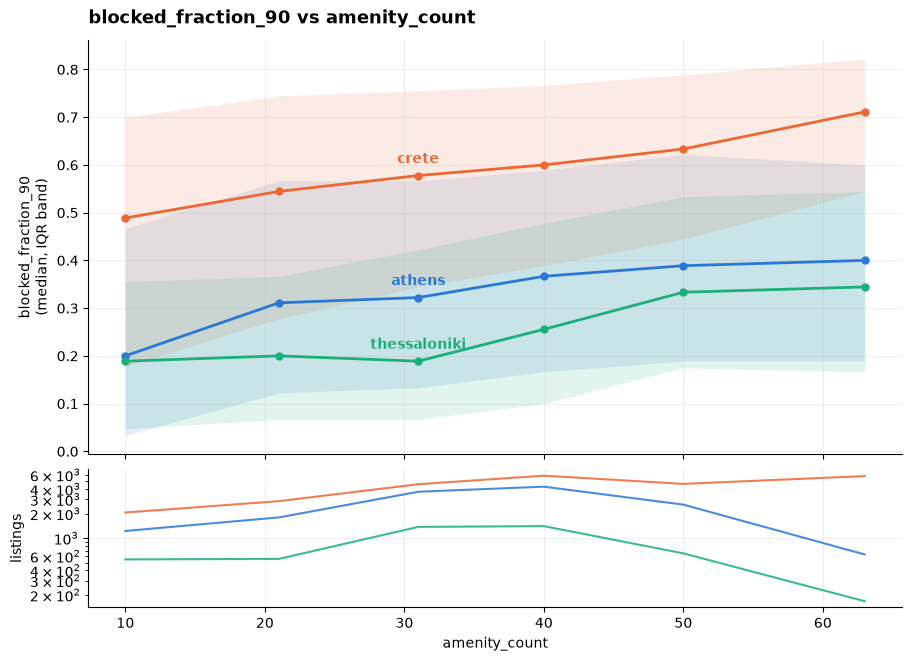

In [9]:
eda.plot_binned_relationship(
    matrix["amenity_count"],
    matrix[LABEL],
    group=matrix["city"].astype(str),
    bins=[0, 15, 25, 35, 45, 55, 200],
);

In [10]:
within = []
for _, g in matrix.groupby(QG, observed=True):
    if len(g) > 10 and g[LABEL].nunique() > 1 and g["amenity_count"].nunique() > 1:
        within.append(spearmanr(g["amenity_count"], g[LABEL]).statistic)
within = np.array([r for r in within if not np.isnan(r)])

pd.Series(
    {
        "overall Spearman": round(spearmanr(matrix["amenity_count"], matrix[LABEL]).statistic, 3),
        "groups scored (n > 10)": len(within),
        "mean within-group Spearman": round(within.mean(), 3),
        "share of groups positive": f"{(within > 0).mean() * 100:.1f} %",
        "within / overall variance": round(
            matrix.groupby(QG, observed=True)["amenity_count"].var().mean()
            / matrix["amenity_count"].var(),
            3,
        ),
    }
).to_frame("value")

,value
overall Spearman,0.244
groups scored (n > 10),292
mean within-group Spearman,0.114
share of groups positive,76.0 %
within / overall variance,0.71


**The relation is monotonic and positive, and it survives the within-group test.** Mean label rises
0.375 → 0.631 across the count bands with no reversal. Overall Spearman is **0.244**; *within*
query groups it falls to **0.114**, positive in **76 %** of the 292 groups scored. The variance
ratio is **0.71**, so unlike the neighbourhood and spatial blocks, this feature does vary
between listings competing with each other.

Amenity count is entangled with listing establishment,
the same confound notebook 02 §4 measured for everything else, and better-equipped listings
are also older and better-reviewed. But, nothing here says adding a coffee machine changes
anything, it says the count carries usable within-group signal, which is what a ranker needs.

**98.7 % of the vocabulary and 98.9 % of 1.74 M mentions land in a bucket**, so the unmapped
tail really is a tail rather than a category being dropped.

**Rarity is not value.** *Body soap* appears on **49.5 %** of listings and *Air conditioning*
on **70.6 %**, so an inverse-frequency weighting would score body soap as the more distinctive
amenity in a Mediterranean summer market.

## 6. Reviews: why the raw rating does not appear

We choose to replace `review_scores_rating` with `rating_shrunk` :

$$\text{rating\_shrunk} = \frac{n \cdot \text{rating} + k \cdot \text{city mean}}{n + k},
\qquad k = 20$$

The idea: a 5.0 from one guest and a 4.9 from four hundred are not the same claim, but the
raw column states them as if they were. Shrinkage pulls a thinly-evidenced rating toward the
city average, in proportion to how thin the evidence is (*k* reads as "the prior is worth
20 pseudo-reviews"). Formally, this is the posterior mean under a Beta-Binomial prior.

**What the table below shows.** What that does to listings at different review counts.

In [11]:
bands = pd.cut(
    matrix["number_of_reviews"],
    [-0.5, 0.5, 1.5, 5.5, 20.5, 100.5, 1e6],
    labels=["0", "1", "2-5", "6-20", "21-100", "100+"],
)
rated = matrix[matrix["has_reviews"]]

pd.DataFrame(
    {
        "listings": bands.value_counts().sort_index(),
        "mean rating_shrunk": matrix.groupby(bands, observed=True)["rating_shrunk"].mean().round(3),
        "sd rating_shrunk": matrix.groupby(bands, observed=True)["rating_shrunk"].std().round(3),
    }
)

,listings,mean rating_shrunk,sd rating_shrunk
number_of_reviews,,,
0,7293,4.821,0.039
1,3141,4.815,0.056
2-5,6949,4.811,0.072
6-20,10053,4.817,0.093
21-100,12588,4.832,0.110
100+,4660,4.837,0.113


**The spread widens as evidence accumulates.** Listings with
a single review are pulled tight around the city mean; the 100+ band is allowed to spread out
and say something while never-reviewed listings are pulled all the way to the prior, which means we know nothing about them beyond their market.

This also means the cold-start cohort enters ranking with a *defined* rating rather than a
NaN, while `has_reviews` still marks the cohort explicitly.

## 7. The aggregate that is not here, and why leave-one-out does not save it

An obvious neighbourhood-level feature is "mean label of my neighbours" computed leave-one-out 
(each listing's own value excluded from its average). It is a completely standard construction, but it doesn't work here.

**What the cell below shows.** For 365 of the 393 query groups, every listing comes from the same neighbourhood.

If we calculate “the average label of the other listings in my neighbourhood,” a listing with a higher own label automatically gets a lower average-of-others value, and vice versa. That happens because the group total is fixed and removing a larger value leaves a smaller remainder.

So this feature is not independent neighbourhood information.

In [12]:
key = ["city", "neighbourhood_cleansed"]
grp = ranked.groupby(key, observed=True)[LABEL]
ranked["loo_nbhd_label"] = (grp.transform("sum") - ranked[LABEL]) / (grp.transform("size") - 1)

nested = ranked.groupby("query_group", observed=True)["neighbourhood_cleansed"].nunique()
nested_groups = nested[nested == 1].index

rhos = []
for _, blk in ranked[ranked["query_group"].isin(nested_groups)].groupby("query_group", observed=True):
    b = blk.dropna(subset=["loo_nbhd_label"])
    if len(b) > 2 and b[LABEL].nunique() > 1:
        rhos.append(spearmanr(b["loo_nbhd_label"], b[LABEL]).statistic)

rhos = np.array([r for r in rhos if not np.isnan(r)])
pd.Series(
    {
        "query groups nested in one neighbourhood": f"{len(nested_groups)} of {ranked['query_group'].nunique()}",
        "groups scored": len(rhos),
        "mean within-group Spearman": round(rhos.mean(), 4),
        "share at exactly -1.000": f"{(rhos <= -0.9999).mean() * 100:.1f} %",
    }
).to_frame("value")

,value
query groups nested in one neighbourhood,365 of 393
groups scored,363
mean within-group Spearman,-1.0
share at exactly -1.000,100.0 %


**Spearman is exactly −1 in 100 % of the 363 groups scored.** Leave-one-out created a target leak here, as it is a perfectly deterministic function of the label in the opposite direction. Ie, the higher label a listing has, the lower its leave-one-out neighbourhood label mean will be.

**What the cell below shows.** The neighbourhood-level aggregates included are: `nbhd_listings`,
`nbhd_median_price`, `price_vs_nbhd`, all built from `price`, and all leave-one-out. Here is how much leave-one-out
actually moves at this scale.

In [13]:
from rental_ranking.features.aggregates import leave_one_out_median

nbhd = ranked["city"].astype(str) + "|" + ranked["neighbourhood_cleansed"].astype(str)
plain = ranked.groupby(nbhd)["price"].transform("median")
loo = leave_one_out_median(ranked["price"], nbhd)
gap = (loo - plain).abs()

pd.Series(
    {
        "neighbourhoods": nbhd.nunique(),
        "median neighbourhood size": int(nbhd.value_counts().median()),
        "mean |LOO - plain| (EUR)": round(gap.mean(), 3),
        "as % of median price": round(gap.mean() / ranked["price"].median() * 100, 3),
    }
).to_frame("value")

,value
neighbourhoods,75.000
median neighbourhood size,168.000
mean |LOO - plain| (EUR),0.112
as % of median price,0.093


**Leave-one-out changes the neighbourhood median price by only €0.112 on average.**
Relative to the overall median listing price of about €120, that is just **0.093 %**.

This is expected: the median neighbourhood contains 168 listings, so removing one listing rarely
changes its median price. The adjustment is still kept because it prevents a listing from helping
define its own neighbourhood feature, but at this scale it has almost no numerical effect.

## 8. Spatial features; Crete is not a city

For both Athens and Thessaloniki we define a single landmark and measure each listing's distance to it. For Crete, we define four landmarks, because it is a region rather than a city, and a single centroid would be meaningless for most of it.
This new feature is `km_to_nearest_anchor`.

**What the table below shows.** The properties of the geographic bounding boxes of each city.

In [14]:
extent = ranked.groupby("city", observed=True).agg(
    lat_km=("latitude", lambda s: (s.max() - s.min()) * 111.0),
    lon_km=("longitude", lambda s: 0.0),
)
extent["lon_km"] = ranked.groupby("city", observed=True).apply(
    lambda g: (g["longitude"].max() - g["longitude"].min())
    * 111.0
    * np.cos(np.radians(g["latitude"].mean())),
    include_groups=False,
)
extent["anchors"] = pd.Series({c: len(ANCHORS[c]) for c in ANCHORS})
display(extent.round(1).reindex(CITIES))

matrix.groupby(matrix["city"].astype(str), observed=True)[
    ["km_to_nearest_anchor", "km_to_neighbourhood_centroid", "density_1km"]
].median().round(2).reindex(CITIES)

,lat_km,lon_km,anchors
city,,,
thessaloniki,13.5,17.8,1
athens,9.0,7.0,1
crete,84.3,248.5,4


,km_to_nearest_anchor,km_to_neighbourhood_centroid,density_1km
city,,,
thessaloniki,1.23,0.99,1677.5
athens,1.46,0.35,2546.0
crete,12.38,4.53,107.0


**Crete spans roughly 250 × 85 km against Athens' 9 × 7.** A feature phrased "distance to the
centre" would have been meaningless for the 58 % of the population that lives there. The four anchors (Chania, Rethymno, Heraklion, Agios
Nikolaos) give every Cretan listing a real reference point.

Note the median distances after that fix: Crete's `km_to_nearest_anchor` is still far larger
than either city's. The anchor set makes the feature meaningful but not uniform.

## 9. Sentiment: piloted, measured, rejected

We had intended to use review-text sentiment scores as a feature using multilingual BERT model. It was run
locally over a sample (no Azure compute spent), using `torch`/`transformers` in `uv.lock`. We scored it against the label and led to three findings:

- **Within query groups it adds +0.015 over the rating.**
- **Among listings at the rating ceiling it correlates −0.026 with the label.** This was the
  strongest argument *for* sentiment (de-compressing the pile-up of 5.0 ratings) and it
  points the wrong way.
- **Airbnb's own `review_scores_value` beats it 2.6× and is free.** 

Sentiment mining still exists **as an Azure AI Language demonstration**, showing
the cloud NLP workflow at `cloud/sentiment.py`.

## 10. The frozen baselines, and the floor to read them against

Since all of the training features are decided, we decided to freeze some scoring baselines before any model exists.
As we saw in Notebook 02 §4, the label is substantially
establishment-driven, so a "rank by review count" is expected to be meaningful.
The second baseline is a within-group ranking established by ratings and price.

**What the table below shows.** The two baselines and a random shuffle, on the full population.

In [ ]:
from rental_ranking.evaluate.metrics import evaluate_ranking, size_band
from rental_ranking.train.baseline import rank_by_price_and_rating, rank_by_reviews

rng = np.random.default_rng(0)
rankers = {
    "A: number_of_reviews": rank_by_reviews(matrix),
    "B: price + rating_shrunk": rank_by_price_and_rating(matrix, QG),
    "C: random shuffle": pd.Series(rng.random(len(matrix)), index=matrix.index),
}
pd.concat(
    {name: evaluate_ranking(matrix["grade"], QG, s).loc[["overall"]] for name, s in rankers.items()}
).droplevel(1).round(4)

,groups,degenerate,ndcg@10,ndcg_low,ndcg_high,recall@10,recall_low,recall_high
A: number_of_reviews,393,10,0.6424,0.6234,0.6612,0.4753,0.4374,0.5140
B: price + rating_shrunk,393,10,0.6218,0.6021,0.6411,0.4568,0.4188,0.4940
random control,393,10,0.5414,0.5215,0.5616,0.4377,0.3996,0.4769


**The floor is ~0.54, not zero.**
So the usable range is **0.54 → 1.00**.

**Review count beats price + rating**, 0.6424 to 0.6218, with overlapping intervals. That
ordering is what notebook 02 §4 predicted from the label's two-stage structure.

**What the next table shows.** Baseline A broken out by group size.

In [16]:
def band_order(index: pd.Index) -> list:
    return sorted(index, key=lambda s: -1 if s == "overall" else int(str(s).split("-")[0]))


bands_table = evaluate_ranking(
    matrix["grade"], QG, rankers["A: number_of_reviews"], breakdown=size_band(QG)
)
bands_table.reindex(band_order(bands_table.index)).round(4)

,groups,degenerate,ndcg@10,ndcg_low,ndcg_high,recall@10,recall_low,recall_high
slice,,,,,,,,
overall,393,10,0.6424,0.6234,0.6612,0.4753,0.4374,0.5140
1-10,101,10,0.8069,0.7738,0.8376,1.0000,1.0000,1.0000
11-50,149,0,0.6061,0.5807,0.6330,0.5429,0.5039,0.5849
51-200,83,0,0.5407,0.5071,0.5746,0.1501,0.1343,0.1667
201-10000,60,0,0.6239,0.5835,0.6676,0.0401,0.0354,0.0448


**NDCG@10 is the main metric.** Recall@10 is not comparable across these groups: it is
automatically 1.0 when a group has ten or fewer listings, while it must be low in very large
groups because only ten listings can be returned.

**Ten groups have one grade only, so they cannot test ranking.** They are excluded from the NDCG
average rather than counted as a perfect score.

**The 51–200-listing groups are the key challenge.** The review-count baseline scores 0.5407
there (essentially random), so this is where the model needs to add value.

## 11. Limitations

Stated once here rather than scattered through the notebook.

- **Nothing here shows a feature *helps*.** The next notebook will deal with that.
- **The amenity map is a judgement call.** Possible alternatives will be scored in the next notebook.
- **`building_type` has 58 values and a long tail.** LightGBM's native categorical splits
  handle it, but rare levels get little support and their splits will be noisy.
- **The neighbourhood aggregates are near-constant within groups**
- **The group-size spread is extreme** : 2 to 2,088. Pooled metrics are heavily caveated, which is why §10 bands them.
- **Seven groups sit under the minimum size** with nowhere further to fall, and 10 are
  degenerate. NDCG@10 here carries no information.
- **Nothing here is validated across time.** 
- **The cold-start cohort is 16.3 % and enters ranking with a prior, not evidence.**

**What carries forward to training**

- the feature matrix, sorted and checked,
- two frozen baselines: **0.6424** and **0.6218** and a **0.5424** random floor to read them
  against
- `evaluate/metrics.py`, which bootstraps over groups and returns NaN for the 10 degenerate
  ones